# 05 - Final Clean 36x124 Training

Train the selected clean `36x124` `PlateCNN` configuration for 10 epochs on the final custom plate-crop dataset.

This notebook keeps the configuration from notebook 04 for the selected model and adds callback-style training controls:

- best-checkpoint saving on validation full-plate accuracy
- last-checkpoint saving every epoch
- `ReduceLROnPlateau` learning-rate scheduling when validation accuracy stalls
- optional promotion of the best checkpoint to `plate_cnn_final.pt`


## 1. Setup and Final Configuration

In [14]:
from __future__ import annotations

import random
import shutil
import sys
from pathlib import Path
from typing import Any

import cv2
import matplotlib.pyplot as plt
import pandas as pd
import torch
from IPython.display import Markdown, display
from torch.utils.data import DataLoader


def find_anpr_project_root() -> Path:
    """Find the uk_plate_recognition project root from common notebook launch locations."""
    cwd = Path.cwd().resolve()
    candidates = [
        cwd,
        cwd.parent,
        cwd.parent.parent,
        cwd / "uk_plate_recognition",
        cwd.parent / "uk_plate_recognition",
    ]

    for candidate in candidates:
        if (candidate / "src" / "anpr").exists() and (candidate / "data").exists():
            return candidate.resolve()

    raise FileNotFoundError(
        "Could not find uk_plate_recognition project root. "
        "Run this notebook from the repository root, uk_plate_recognition/, or uk_plate_recognition/notebooks/."
    )


PROJECT_ROOT = find_anpr_project_root()
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from anpr.data.dataset import PlateDataset
from anpr.data.metadata import build_metadata_csv
from anpr.data.transforms import get_eval_transforms, get_stress_test_transforms
from anpr.evaluation.metrics import format_plate_metrics
from anpr.inference.decode import decode_model_outputs
from anpr.models.plate_cnn import PlateCNN, count_trainable_parameters
from anpr.training.losses import PlateMultiHeadLoss
from anpr.training.train_loop import evaluate_one_epoch, train_one_epoch

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RANDOM_STATE = 42
random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_STATE)

FINAL_DATASET_DIR = PROJECT_ROOT / "data" / "raw" / "plate_crops_LLNNLLL_2"
METADATA_CSV = PROJECT_ROOT / "data" / "metadata" / "plates_custom_final.csv"
INVALID_METADATA_CSV = PROJECT_ROOT / "data" / "metadata" / "invalid_plates_custom_final.csv"

CHECKPOINT_DIR = PROJECT_ROOT / "checkpoints" / "custom_data_cnn_v2"
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "custom_dataset_training"
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

EXPERIMENT_NAME = "final_clean_36x124_10ep"
IMAGE_HEIGHT = 36
IMAGE_WIDTH = 124
TRAIN_AUGMENTED = False

BATCH_SIZE = 64
NUM_EPOCHS = 20
LR = 1e-3
WEIGHT_DECAY = 1e-4
DROPOUT = 0.1
POOLED_WIDTH = 10
PLATE_LENGTH = 7
NUM_WORKERS = 0

SCHEDULER_FACTOR = 0.5
SCHEDULER_PATIENCE = 2
MIN_LR = 1e-5

BEST_CHECKPOINT_PATH = CHECKPOINT_DIR / f"{EXPERIMENT_NAME}_best.pt"
LAST_CHECKPOINT_PATH = CHECKPOINT_DIR / f"{EXPERIMENT_NAME}_last.pt"
FINAL_CHECKPOINT_PATH = CHECKPOINT_DIR / "plate_cnn_final.pt"

print("Project root:", PROJECT_ROOT)
print("Dataset:", FINAL_DATASET_DIR)
print("Metadata:", METADATA_CSV)
print("Device:", DEVICE)
print("Experiment:", EXPERIMENT_NAME)
print("Image size:", (IMAGE_HEIGHT, IMAGE_WIDTH))
print("Epochs:", NUM_EPOCHS)


Project root: C:\Users\kosko\OneDrive\Python\machine_learning\Projects\Car-Parking\uk_plate_recognition
Dataset: C:\Users\kosko\OneDrive\Python\machine_learning\Projects\Car-Parking\uk_plate_recognition\data\raw\plate_crops_LLNNLLL_2
Metadata: C:\Users\kosko\OneDrive\Python\machine_learning\Projects\Car-Parking\uk_plate_recognition\data\metadata\plates_custom_final.csv
Device: cpu
Experiment: final_clean_36x124_10ep
Image size: (36, 124)
Epochs: 20


## 2. Rebuild Metadata

In [10]:
if not FINAL_DATASET_DIR.exists():
    raise FileNotFoundError(f"Final dataset folder not found: {FINAL_DATASET_DIR}")

metadata_df = build_metadata_csv(
    image_dir=FINAL_DATASET_DIR,
    output_csv=METADATA_CSV,
    invalid_csv=INVALID_METADATA_CSV,
    project_root=PROJECT_ROOT,
    source_name="plate_crops_LLNNLLL_2",
    allow_embedded_plate=True,
    random_state=RANDOM_STATE,
)

print("Saved metadata:", METADATA_CSV)
print("Rows:", len(metadata_df))
display(metadata_df.head())
display(metadata_df["split"].value_counts().rename_axis("split").reset_index(name="images"))
display(metadata_df["label"].value_counts().describe().to_frame("images_per_label"))


Saved metadata: C:\Users\kosko\OneDrive\Python\machine_learning\Projects\Car-Parking\uk_plate_recognition\data\metadata\plates_custom_final.csv
Rows: 12221


,image_id,image_path,label,label_length,source,split
0,AC08UHJ,data/raw/plate_crops_LLNNLLL_2/AC08UHJ.jpg,AC08UHJ,7,plate_crops_LLNNLLL_2,val
1,AC08UHJ_002,data/raw/plate_crops_LLNNLLL_2/AC08UHJ_002.jpg,AC08UHJ,7,plate_crops_LLNNLLL_2,val
2,AC21AJW,data/raw/plate_crops_LLNNLLL_2/AC21AJW.jpg,AC21AJW,7,plate_crops_LLNNLLL_2,train
3,AD08CAO,data/raw/plate_crops_LLNNLLL_2/AD08CAO.jpg,AD08CAO,7,plate_crops_LLNNLLL_2,train
4,AD08CAO_002,data/raw/plate_crops_LLNNLLL_2/AD08CAO_002.jpg,AD08CAO,7,plate_crops_LLNNLLL_2,train


,split,images
0,train,9784
1,test,1231
2,val,1206


,images_per_label
count,11156.000000
mean,1.095464
std,0.388232
min,1.000000
25%,1.000000
50%,1.000000
75%,1.000000
max,6.000000


## 3. Datasets and Loaders

In [11]:
def md(text: str) -> None:
    display(Markdown(text))


def build_datasets() -> tuple[PlateDataset, PlateDataset, PlateDataset]:
    transform = get_eval_transforms(
        image_height=IMAGE_HEIGHT,
        image_width=IMAGE_WIDTH,
    )

    def dataset_for(split: str) -> PlateDataset:
        return PlateDataset(
            metadata=METADATA_CSV,
            project_root=PROJECT_ROOT,
            split=split,
            transform=transform,
            grayscale=True,
        )

    return dataset_for("train"), dataset_for("val"), dataset_for("test")


def make_loaders(
    train_ds: PlateDataset,
    val_ds: PlateDataset,
    test_ds: PlateDataset,
    batch_size: int = BATCH_SIZE,
) -> tuple[DataLoader, DataLoader, DataLoader]:
    loader_kwargs = {
        "batch_size": batch_size,
        "num_workers": NUM_WORKERS,
        "pin_memory": torch.cuda.is_available(),
    }
    return (
        DataLoader(train_ds, shuffle=True, **loader_kwargs),
        DataLoader(val_ds, shuffle=False, **loader_kwargs),
        DataLoader(test_ds, shuffle=False, **loader_kwargs),
    )


train_ds, val_ds, test_ds = build_datasets()
train_loader, val_loader, test_loader = make_loaders(train_ds, val_ds, test_ds)

print("Dataset sizes:", len(train_ds), len(val_ds), len(test_ds))
sample = train_ds[0]
print("Sample image shape:", tuple(sample["image"].shape))
print("Sample target shape:", tuple(sample["target"].shape))
print("Sample label:", sample["label"])

batch = next(iter(train_loader))
print("Batch image shape:", tuple(batch["image"].shape))
print("Batch target shape:", tuple(batch["target"].shape))


Dataset sizes: 9784 1206 1231
Sample image shape: (1, 36, 124)
Sample target shape: (7,)
Sample label: AC21AJW
Batch image shape: (64, 1, 36, 124)
Batch target shape: (64, 7)


## 4. Visual Sanity Check

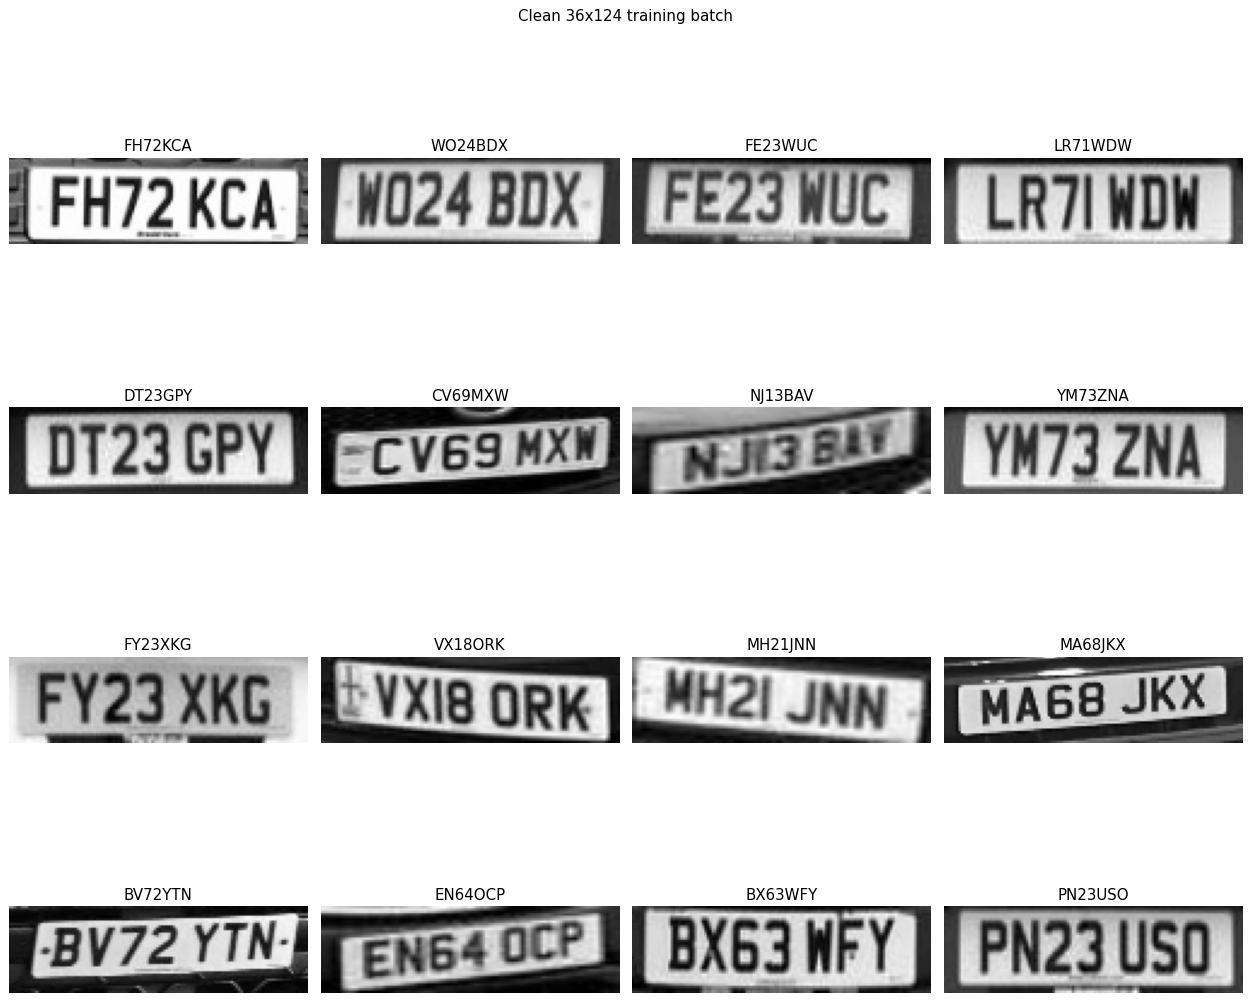

In [12]:
def denormalise_plate_tensor(image_tensor: torch.Tensor):
    image = image_tensor.squeeze(0).detach().cpu().numpy()
    image = (image * 0.5) + 0.5
    return image.clip(0, 1)


def show_batch(dataset: PlateDataset, title: str, num_images: int = 16) -> None:
    loader = DataLoader(dataset, batch_size=num_images, shuffle=True, num_workers=0)
    batch = next(iter(loader))
    cols = 4
    rows = (min(num_images, len(batch["label"])) + cols - 1) // cols
    plt.figure(figsize=(14, 3.2 * rows), dpi=90)
    for index in range(min(num_images, len(batch["label"]))):
        plt.subplot(rows, cols, index + 1)
        plt.imshow(denormalise_plate_tensor(batch["image"][index]), cmap="gray")
        plt.title(batch["label"][index])
        plt.axis("off")
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


show_batch(train_ds, "Clean 36x124 training batch", num_images=16)


## 5. Training Helpers

In [13]:
def build_model() -> PlateCNN:
    return PlateCNN(in_channels=1, dropout=DROPOUT, pooled_width=POOLED_WIDTH).to(DEVICE)


def get_current_lr(optimizer: torch.optim.Optimizer) -> float:
    return float(optimizer.param_groups[0]["lr"])


def history_row(epoch: int, train_result, val_result, lr: float) -> dict[str, Any]:
    metrics = val_result.metrics
    row = {
        "epoch": epoch,
        "lr": lr,
        "train_loss": train_result.loss,
        "val_loss": val_result.loss,
        "val_full_plate_accuracy": metrics.full_plate_accuracy,
        "val_regex_valid_rate": metrics.regex_valid_rate,
        "val_average_confidence": metrics.average_confidence,
    }
    for position, accuracy in enumerate(metrics.per_position_accuracy):
        row[f"val_position_{position}_acc"] = accuracy
    return row


def make_checkpoint_payload(
    model: PlateCNN,
    optimizer: torch.optim.Optimizer,
    scheduler: torch.optim.lr_scheduler.ReduceLROnPlateau,
    epoch: int,
    best_val_accuracy: float,
    best_val_loss: float,
    history: list[dict[str, Any]],
) -> dict[str, Any]:
    return {
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict(),
        "epoch": epoch,
        "best_val_accuracy": best_val_accuracy,
        "best_val_loss": best_val_loss,
        "history": history,
        "model_config": {
            "in_channels": 1,
            "dropout": DROPOUT,
            "pooled_width": POOLED_WIDTH,
            "image_height": IMAGE_HEIGHT,
            "image_width": IMAGE_WIDTH,
            "grayscale": True,
        },
        "experiment_config": {
            "experiment_name": EXPERIMENT_NAME,
            "train_augmented": TRAIN_AUGMENTED,
            "metadata_csv": str(METADATA_CSV),
            "dataset_dir": str(FINAL_DATASET_DIR),
            "num_epochs": NUM_EPOCHS,
            "lr": LR,
            "weight_decay": WEIGHT_DECAY,
            "batch_size": BATCH_SIZE,
            "random_state": RANDOM_STATE,
        },
        "callback_config": {
            "checkpoint_monitor": "val_full_plate_accuracy",
            "checkpoint_mode": "max",
            "scheduler": "ReduceLROnPlateau",
            "scheduler_monitor": "val_full_plate_accuracy",
            "scheduler_mode": "max",
            "scheduler_factor": SCHEDULER_FACTOR,
            "scheduler_patience": SCHEDULER_PATIENCE,
            "min_lr": MIN_LR,
        },
    }


def save_training_checkpoint(
    path: Path,
    model: PlateCNN,
    optimizer: torch.optim.Optimizer,
    scheduler: torch.optim.lr_scheduler.ReduceLROnPlateau,
    epoch: int,
    best_val_accuracy: float,
    best_val_loss: float,
    history: list[dict[str, Any]],
) -> None:
    payload = make_checkpoint_payload(
        model=model,
        optimizer=optimizer,
        scheduler=scheduler,
        epoch=epoch,
        best_val_accuracy=best_val_accuracy,
        best_val_loss=best_val_loss,
        history=history,
    )
    torch.save(payload, path)


def load_checkpoint_model(checkpoint_path: Path) -> tuple[PlateCNN, dict[str, Any]]:
    checkpoint = torch.load(checkpoint_path, map_location=DEVICE)
    config = checkpoint["model_config"]
    model = PlateCNN(
        in_channels=config["in_channels"],
        dropout=config["dropout"],
        pooled_width=config["pooled_width"],
    ).to(DEVICE)
    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()
    return model, checkpoint


def evaluate_model(model: PlateCNN, loader: DataLoader, label: str):
    result = evaluate_one_epoch(model, loader, PlateMultiHeadLoss(), DEVICE, show_progress=True)
    print(f"{label} loss:", result.loss)
    print(format_plate_metrics(result.metrics))
    return result


def export_predictions(model: PlateCNN, loader: DataLoader, filename: str) -> pd.DataFrame:
    rows = []
    model.eval()
    with torch.no_grad():
        for batch in loader:
            images = batch["image"].to(DEVICE)
            labels = list(batch["label"])
            image_paths = list(batch["image_path"])
            predictions = decode_model_outputs(model(images))

            for image_path, true_label, prediction in zip(image_paths, labels, predictions):
                predicted_label = prediction.cleaned_prediction
                row = {
                    "image_path": image_path,
                    "true_label": true_label,
                    "predicted_label": predicted_label,
                    "correct": predicted_label == true_label,
                    "confidence": prediction.overall_confidence,
                    "regex_valid": prediction.is_valid_format,
                }
                for position in range(PLATE_LENGTH):
                    row[f"true_pos_{position}"] = true_label[position]
                    row[f"pred_pos_{position}"] = predicted_label[position]
                    row[f"pos_{position}_correct"] = true_label[position] == predicted_label[position]
                    row[f"pos_{position}_confidence"] = prediction.position_confidences[position]
                rows.append(row)

    predictions_df = pd.DataFrame(rows)
    output_path = OUTPUT_DIR / filename
    predictions_df.to_csv(output_path, index=False)
    print("Saved predictions:", output_path)
    return predictions_df


def plot_history(history_df: pd.DataFrame, title: str) -> None:
    plt.figure(figsize=(8, 5))
    plt.plot(history_df["epoch"], history_df["train_loss"], label="Train loss")
    plt.plot(history_df["epoch"], history_df["val_loss"], label="Val loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{title} loss")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(history_df["epoch"], history_df["val_full_plate_accuracy"], label="Val full-plate accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"{title} validation accuracy")
    plt.ylim(0, 1)
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(history_df["epoch"], history_df["lr"], label="Learning rate used")
    if "next_lr" in history_df.columns:
        plt.plot(history_df["epoch"], history_df["next_lr"], label="Learning rate for next epoch", linestyle="--")
    plt.xlabel("Epoch")
    plt.ylabel("Learning rate")
    plt.title(f"{title} learning rate")
    plt.legend()
    plt.grid(True)
    plt.show()


## 6. Train Final Model

=== final_clean_36x124_10ep ===
Image size: (36, 124)
Clean training transforms: True
Trainable parameters: 772470
Best checkpoint: C:\Users\kosko\OneDrive\Python\machine_learning\Projects\Car-Parking\uk_plate_recognition\checkpoints\custom_data_cnn_v2\final_clean_36x124_10ep_best.pt
Last checkpoint: C:\Users\kosko\OneDrive\Python\machine_learning\Projects\Car-Parking\uk_plate_recognition\checkpoints\custom_data_cnn_v2\final_clean_36x124_10ep_last.pt


Training:   0%|          | 0/153 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/19 [00:00<?, ?it/s]

Epoch 01 | lr=1.00e-03 -> 1.00e-03 | train_loss=1.6442 | val_loss=0.6432 | val_full_plate_acc=0.2753 | confidence=0.6926 | saved_best=True


Training:   0%|          | 0/153 [00:00<?, ?it/s]

...

Epoch 19 | lr=5.00e-04 -> 5.00e-04 | train_loss=0.0008 | val_loss=0.0327 | val_full_plate_acc=0.9561 | confidence=0.9928


Training:   0%|          | 0/153 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/19 [00:00<?, ?it/s]

Epoch 20 | lr=5.00e-04 -> 5.00e-04 | train_loss=0.0013 | val_loss=0.0339 | val_full_plate_acc=0.9585 | confidence=0.9928
Saved history: C:\Users\kosko\OneDrive\Python\machine_learning\Projects\Car-Parking\uk_plate_recognition\outputs\custom_dataset_training\final_clean_36x124_10ep_history.csv


,epoch,lr,train_loss,val_loss,val_full_plate_accuracy,val_regex_valid_rate,val_average_confidence,val_position_0_acc,val_position_1_acc,val_position_2_acc,val_position_3_acc,val_position_4_acc,val_position_5_acc,val_position_6_acc,next_lr
0,1,0.0010,1.644222,0.643208,0.275290,1.0,0.692621,0.828358,0.786070,0.932007,0.918740,0.757048,0.687396,0.759536,0.0010
1,2,0.0010,0.314811,0.155031,0.841625,1.0,0.911895,0.978441,0.970978,0.980929,0.966833,0.961028,0.931177,0.964345,0.0010
2,3,0.0010,0.113082,0.088663,0.901327,1.0,0.955083,0.985075,0.978441,0.990050,0.983416,0.976783,0.946932,0.983416,0.0010
3,4,0.0010,0.062448,0.066054,0.924544,1.0,0.969835,0.990879,0.983416,0.991708,0.981758,0.980100,0.966833,0.985075,0.0010
4,5,0.0010,0.037810,0.060534,0.927861,1.0,0.976908,0.991708,0.984245,0.993367,0.984245,0.984245,0.960199,0.987562,0.0010
5,6,0.0010,0.026491,0.078026,0.889718,1.0,0.973212,0.985075,0.978441,0.991708,0.970978,0.977612,0.955224,0.986733,0.0010
6,7,0.0010,0.018093,0.050945,0.926202,1.0,0.983612,0.990879,0.984245,0.989221,0.986733,0.989221,0.962687,0.987562,0.0010
7,8,0.0010,0.014701,0.046752,0.943615,1.0,0.983734,0.992537,0.986733,0.994196,0.987562,0.990879,0.967662,0.993367,0.0010
8,9,0.0010,0.009760,0.045512,0.936153,1.0,0.986550,0.994196,0.988391,0.994196,0.987562,0.990879,0.968491,0.982587,0.0010
9,10,0.0010,0.009173,0.045111,0.932836,1.0,0.987630,0.990879,0.986733,0.986733,0.985075,0.992537,0.965174,0.990050,0.0010


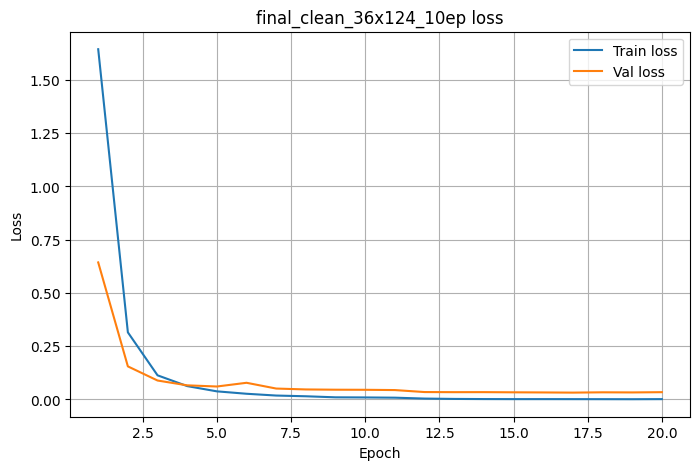

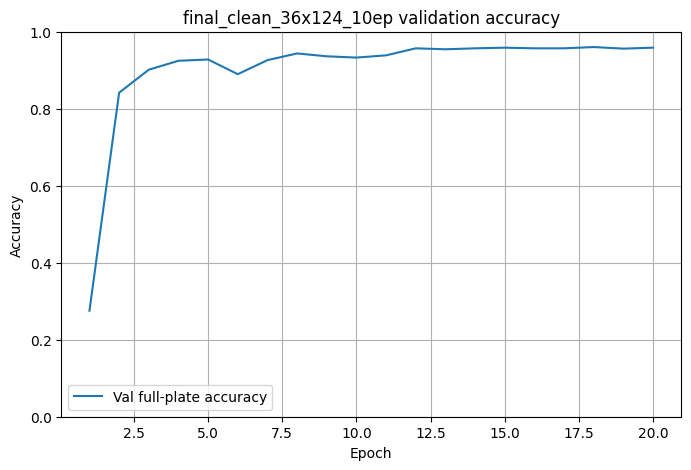

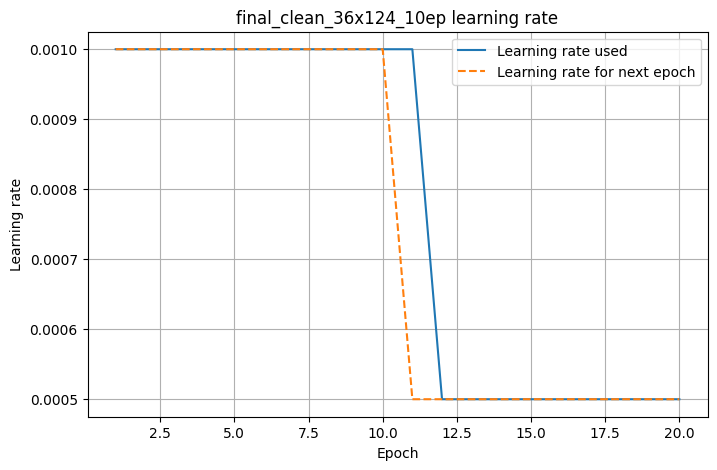

In [15]:
model = build_model()
loss_fn = PlateMultiHeadLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=SCHEDULER_FACTOR,
    patience=SCHEDULER_PATIENCE,
    min_lr=MIN_LR,
)

best_val_accuracy = -1.0
best_val_loss = float("inf")
history: list[dict[str, Any]] = []

print(f"=== {EXPERIMENT_NAME} ===")
print("Image size:", (IMAGE_HEIGHT, IMAGE_WIDTH))
print("Clean training transforms:", not TRAIN_AUGMENTED)
print("Trainable parameters:", count_trainable_parameters(model))
print("Best checkpoint:", BEST_CHECKPOINT_PATH)
print("Last checkpoint:", LAST_CHECKPOINT_PATH)

for epoch in range(1, NUM_EPOCHS + 1):
    lr_used = get_current_lr(optimizer)
    train_result = train_one_epoch(
        model,
        train_loader,
        loss_fn,
        optimizer,
        DEVICE,
        show_progress=True,
    )
    val_result = evaluate_one_epoch(
        model,
        val_loader,
        loss_fn,
        DEVICE,
        show_progress=True,
    )

    row = history_row(epoch, train_result, val_result, lr_used)
    history.append(row)

    scheduler.step(row["val_full_plate_accuracy"])
    row["next_lr"] = get_current_lr(optimizer)

    accuracy_improved = row["val_full_plate_accuracy"] > best_val_accuracy
    loss_tiebreak = (
        row["val_full_plate_accuracy"] == best_val_accuracy
        and row["val_loss"] < best_val_loss
    )
    is_new_best = accuracy_improved or loss_tiebreak

    if is_new_best:
        best_val_accuracy = row["val_full_plate_accuracy"]
        best_val_loss = row["val_loss"]
        save_training_checkpoint(
            BEST_CHECKPOINT_PATH,
            model,
            optimizer,
            scheduler,
            epoch,
            best_val_accuracy,
            best_val_loss,
            history,
        )
        best_marker = " | saved_best=True"
    else:
        best_marker = ""

    save_training_checkpoint(
        LAST_CHECKPOINT_PATH,
        model,
        optimizer,
        scheduler,
        epoch,
        best_val_accuracy,
        best_val_loss,
        history,
    )

    print(
        f"Epoch {epoch:02d} | lr={lr_used:.2e} -> {row['next_lr']:.2e} | "
        f"train_loss={train_result.loss:.4f} | "
        f"val_loss={val_result.loss:.4f} | "
        f"val_full_plate_acc={row['val_full_plate_accuracy']:.4f} | "
        f"confidence={row['val_average_confidence']:.4f}"
        f"{best_marker}"
    )

history_df = pd.DataFrame(history)
history_path = OUTPUT_DIR / f"{EXPERIMENT_NAME}_history.csv"
history_df.to_csv(history_path, index=False)
print("Saved history:", history_path)
display(history_df)
plot_history(history_df, EXPERIMENT_NAME)


## 7. Evaluate Best Checkpoint

In [16]:
best_model, best_checkpoint = load_checkpoint_model(BEST_CHECKPOINT_PATH)
test_result = evaluate_model(best_model, test_loader, f"{EXPERIMENT_NAME} test")

summary_df = pd.DataFrame(
    [
        {
            "experiment": EXPERIMENT_NAME,
            "image_height": IMAGE_HEIGHT,
            "image_width": IMAGE_WIDTH,
            "train_augmented": TRAIN_AUGMENTED,
            "checkpoint_path": str(BEST_CHECKPOINT_PATH),
            "best_epoch": best_checkpoint["epoch"],
            "best_val_accuracy": best_checkpoint["best_val_accuracy"],
            "best_val_loss": best_checkpoint["best_val_loss"],
            "test_loss": test_result.loss,
            "test_full_plate_accuracy": test_result.metrics.full_plate_accuracy,
            "test_regex_valid_rate": test_result.metrics.regex_valid_rate,
            "test_average_confidence": test_result.metrics.average_confidence,
        }
    ]
)
summary_path = OUTPUT_DIR / f"{EXPERIMENT_NAME}_summary.csv"
summary_df.to_csv(summary_path, index=False)
print("Saved summary:", summary_path)
display(summary_df)

predictions_df = export_predictions(
    best_model,
    test_loader,
    f"{EXPERIMENT_NAME}_test_predictions.csv",
)
display(predictions_df.head())


Evaluating:   0%|          | 0/20 [00:00<?, ?it/s]

final_clean_36x124_10ep test loss: 0.0516928645212532
Samples: 1231
Full-plate accuracy: 0.9496
Regex-valid rate: 1.0000
Average confidence: 0.9917
Per-position accuracy:
  Position 0: 0.9968
  Position 1: 0.9959
  Position 2: 0.9951
  Position 3: 0.9870
  Position 4: 0.9862
  Position 5: 0.9724
  Position 6: 0.9870
Saved summary: C:\Users\kosko\OneDrive\Python\machine_learning\Projects\Car-Parking\uk_plate_recognition\outputs\custom_dataset_training\final_clean_36x124_10ep_summary.csv


,experiment,image_height,image_width,train_augmented,checkpoint_path,best_epoch,best_val_accuracy,best_val_loss,test_loss,test_full_plate_accuracy,test_regex_valid_rate,test_average_confidence
0,final_clean_36x124_10ep,36,124,False,C:\Users\kosko\OneDrive\Python\machine_learnin...,18,0.960199,0.033288,0.051693,0.949634,1.0,0.991656


Saved predictions: C:\Users\kosko\OneDrive\Python\machine_learning\Projects\Car-Parking\uk_plate_recognition\outputs\custom_dataset_training\final_clean_36x124_10ep_test_predictions.csv


,image_path,true_label,predicted_label,correct,confidence,regex_valid,true_pos_0,pred_pos_0,pos_0_correct,pos_0_confidence,...,pos_4_correct,pos_4_confidence,true_pos_5,pred_pos_5,pos_5_correct,pos_5_confidence,true_pos_6,pred_pos_6,pos_6_correct,pos_6_confidence
0,C:\Users\kosko\OneDrive\Python\machine_learnin...,AD66UTT,AD66UTT,True,0.998404,True,A,A,True,0.999850,...,True,0.997752,T,T,True,0.998363,T,T,True,0.999984
1,C:\Users\kosko\OneDrive\Python\machine_learnin...,AE23RSO,AE23RSO,True,0.999885,True,A,A,True,0.999894,...,True,0.999993,S,S,True,0.999998,O,O,True,0.999328
2,C:\Users\kosko\OneDrive\Python\machine_learnin...,AE70UUX,AE70UUX,True,0.999688,True,A,A,True,0.999644,...,True,0.999998,U,U,True,0.998406,X,X,True,0.999976
3,C:\Users\kosko\OneDrive\Python\machine_learnin...,AE75XFU,AE75XFU,True,0.999910,True,A,A,True,0.999828,...,True,0.999987,F,F,True,0.999999,U,U,True,0.999978
4,C:\Users\kosko\OneDrive\Python\machine_learnin...,AF23GUJ,AF23GUJ,True,0.990951,True,A,A,True,0.999439,...,True,0.999916,U,U,True,0.938267,J,J,True,0.999970


## 8. Error Analysis

Errors: 62
Accuracy: 0.9496344435418359
Number of errors: 62
Full-plate accuracy: 0.9496344435418359


,image_path,true_label,predicted_label,correct,confidence,regex_valid,true_pos_0,pred_pos_0,pos_0_correct,pos_0_confidence,...,pos_4_correct,pos_4_confidence,true_pos_5,pred_pos_5,pos_5_correct,pos_5_confidence,true_pos_6,pred_pos_6,pos_6_correct,pos_6_confidence
673,C:\Users\kosko\OneDrive\Python\machine_learnin...,LS75PAO,LS75PPO,False,0.997252,True,L,L,True,1.000000,...,True,0.997236,A,P,False,0.984870,O,O,True,0.999931
1214,C:\Users\kosko\OneDrive\Python\machine_learnin...,YW19YHD,YW19YDD,False,0.994009,True,Y,Y,True,0.999997,...,True,0.999988,H,D,False,0.966367,D,D,True,0.991759
806,C:\Users\kosko\OneDrive\Python\machine_learnin...,OE58FCC,OE58FCG,False,0.993465,True,O,O,True,0.999150,...,True,0.999767,C,C,True,0.999991,C,G,False,0.955717
1025,C:\Users\kosko\OneDrive\Python\machine_learnin...,VU19RZB,VU19RZR,False,0.993285,True,V,V,True,0.997726,...,True,0.969152,Z,Z,True,0.999977,B,R,False,0.991914
562,C:\Users\kosko\OneDrive\Python\machine_learnin...,KW20RVL,WW20RVL,False,0.991838,True,K,W,False,0.976518,...,True,0.997277,V,V,True,0.999989,L,L,True,0.999996
660,C:\Users\kosko\OneDrive\Python\machine_learnin...,LS11GBV,LS11GVV,False,0.990551,True,L,L,True,0.999350,...,True,0.957751,B,V,False,0.992726,V,V,True,0.984068
492,C:\Users\kosko\OneDrive\Python\machine_learnin...,HV74XMB,HV74XXB,False,0.987199,True,H,H,True,0.999982,...,True,0.999961,M,X,False,0.912284,B,B,True,0.998338
1161,C:\Users\kosko\OneDrive\Python\machine_learnin...,YH68ZFV,YH68ZZV,False,0.986189,True,Y,Y,True,1.000000,...,True,0.980498,F,Z,False,0.996124,V,V,True,0.991162
1122,C:\Users\kosko\OneDrive\Python\machine_learnin...,YC65GFZ,YC65GGF,False,0.985422,True,Y,Y,True,0.999969,...,True,0.980069,F,G,False,0.920216,Z,F,False,0.999838
757,C:\Users\kosko\OneDrive\Python\machine_learnin...,NA22DHJ,NA22DDJ,False,0.981442,True,N,N,True,0.901475,...,True,0.981969,H,D,False,0.999120,J,J,True,0.992911


,position,accuracy,errors
0,0,0.996751,4
1,1,0.995938,5
2,2,0.995126,6
3,3,0.987002,16
4,4,0.986190,17
5,5,0.972380,34
6,6,0.987002,16


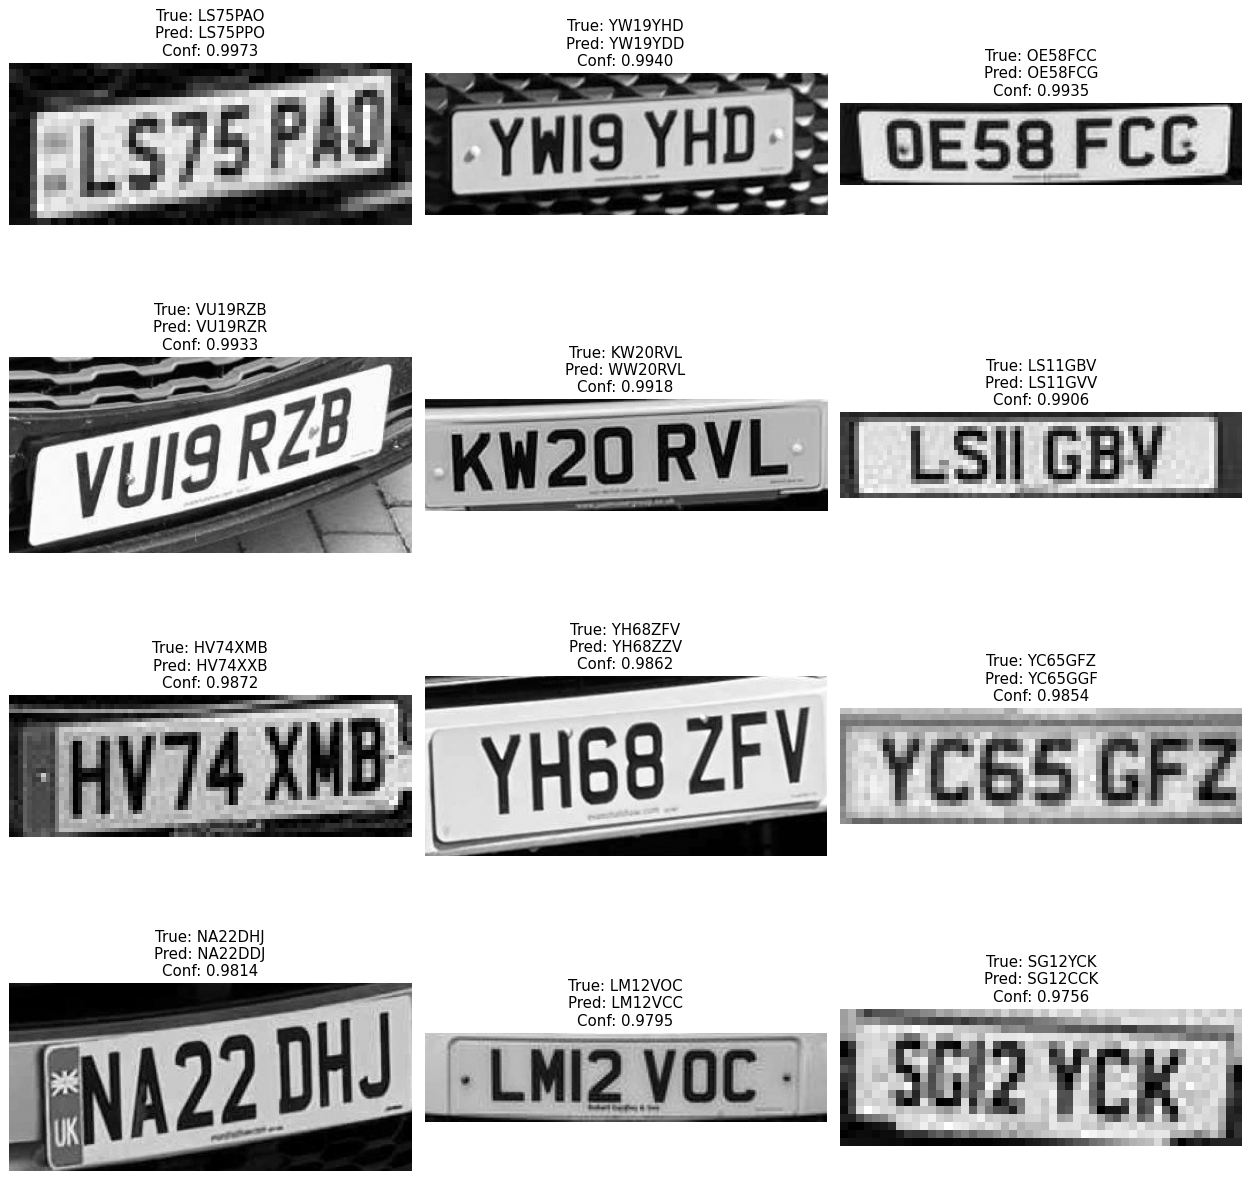

Saved character errors: C:\Users\kosko\OneDrive\Python\machine_learning\Projects\Car-Parking\uk_plate_recognition\outputs\custom_dataset_training\final_clean_36x124_10ep_character_errors.csv


,position,true_char,pred_char,count
23,3,7,0,4
77,6,L,U,3
65,5,U,W,3
66,5,V,N,3
46,5,B,V,2
21,3,6,0,2
52,5,H,D,2
72,6,C,G,2
9,2,0,6,2
76,6,L,C,2


In [17]:
def resolve_image_path(path_value) -> Path:
    path = Path(path_value)
    return path if path.is_absolute() else PROJECT_ROOT / path


def show_error_images(errors_df: pd.DataFrame, max_images: int = 12) -> None:
    rows = errors_df.head(max_images).reset_index(drop=True)
    if rows.empty:
        print("No images to display.")
        return

    cols = 3
    plot_rows = (len(rows) + cols - 1) // cols
    plt.figure(figsize=(14, 3.6 * plot_rows), dpi=90)
    for index, row in rows.iterrows():
        image_path = resolve_image_path(row["image_path"])
        image = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)
        if image is None:
            print("Could not read image:", image_path)
            continue
        plt.subplot(plot_rows, cols, index + 1)
        plt.imshow(image, cmap="gray")
        plt.title(
            f"True: {row['true_label']}\n"
            f"Pred: {row['predicted_label']}\n"
            f"Conf: {row['confidence']:.4f}"
        )
        plt.axis("off")
    plt.tight_layout()
    plt.show()


def inspect_errors(predictions_df: pd.DataFrame, max_rows: int = 20) -> pd.DataFrame:
    errors_df = predictions_df[~predictions_df["correct"]].copy()
    print("Number of errors:", len(errors_df))
    print("Full-plate accuracy:", predictions_df["correct"].mean())
    return errors_df.sort_values("confidence", ascending=False).head(max_rows)


def position_error_summary(predictions_df: pd.DataFrame) -> pd.DataFrame:
    return pd.DataFrame(
        {
            "position": position,
            "accuracy": predictions_df[f"pos_{position}_correct"].mean(),
            "errors": (~predictions_df[f"pos_{position}_correct"]).sum(),
        }
        for position in range(PLATE_LENGTH)
    )


def character_errors(predictions_df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for _, row in predictions_df[~predictions_df["correct"]].iterrows():
        for position in range(PLATE_LENGTH):
            true_char = row["true_label"][position]
            pred_char = row["predicted_label"][position]
            if true_char != pred_char:
                rows.append(
                    {
                        "image_path": row["image_path"],
                        "true_label": row["true_label"],
                        "predicted_label": row["predicted_label"],
                        "position": position,
                        "true_char": true_char,
                        "pred_char": pred_char,
                        "plate_confidence": row["confidence"],
                        "position_confidence": row[f"pos_{position}_confidence"],
                    }
                )
    return pd.DataFrame(rows)


errors_df = predictions_df[~predictions_df["correct"]].copy()
print("Errors:", len(errors_df))
print("Accuracy:", predictions_df["correct"].mean())

display(inspect_errors(predictions_df, max_rows=30))
display(position_error_summary(predictions_df))
show_error_images(errors_df.sort_values("confidence", ascending=False), max_images=12)

char_errors_df = character_errors(predictions_df)
char_errors_path = OUTPUT_DIR / f"{EXPERIMENT_NAME}_character_errors.csv"
char_errors_df.to_csv(char_errors_path, index=False)
print("Saved character errors:", char_errors_path)
if not char_errors_df.empty:
    display(
        char_errors_df.groupby(["position", "true_char", "pred_char"])
        .size()
        .reset_index(name="count")
        .sort_values("count", ascending=False)
        .head(30)
    )


## 9. Optional Stress Evaluation

In [18]:
RUN_STRESS_EVAL = True


def build_stress_loader() -> DataLoader:
    stress_ds = PlateDataset(
        metadata=METADATA_CSV,
        project_root=PROJECT_ROOT,
        split="test",
        transform=get_stress_test_transforms(
            image_height=IMAGE_HEIGHT,
            image_width=IMAGE_WIDTH,
        ),
        grayscale=True,
    )
    return DataLoader(
        stress_ds,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
    )


if RUN_STRESS_EVAL:
    stress_loader = build_stress_loader()
    stress_result = evaluate_model(best_model, stress_loader, f"{EXPERIMENT_NAME} stress")
    stress_summary_df = pd.DataFrame(
        [
            {
                "experiment": EXPERIMENT_NAME,
                "stress_loss": stress_result.loss,
                "stress_full_plate_accuracy": stress_result.metrics.full_plate_accuracy,
                "stress_regex_valid_rate": stress_result.metrics.regex_valid_rate,
                "stress_average_confidence": stress_result.metrics.average_confidence,
            }
        ]
    )
    stress_summary_path = OUTPUT_DIR / f"{EXPERIMENT_NAME}_stress_summary.csv"
    stress_summary_df.to_csv(stress_summary_path, index=False)
    display(stress_summary_df)
    print("Saved stress summary:", stress_summary_path)
else:
    print("Stress evaluation skipped. Set RUN_STRESS_EVAL = True to run it.")


C:\Users\kosko\OneDrive\Python\machine_learning\Projects\Car-Parking\uk_plate_recognition\src\anpr\data\transforms.py:129: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(
C:\Users\kosko\OneDrive\Python\machine_learning\Projects\Car-Parking\uk_plate_recognition\src\anpr\data\transforms.py:134: UserWarning: Argument(s) 'quality_lower, quality_upper' are not valid for transform ImageCompression
  A.ImageCompression(


Evaluating:   0%|          | 0/20 [00:00<?, ?it/s]

final_clean_36x124_10ep stress loss: 1.6526376467037742
Samples: 1231
Full-plate accuracy: 0.6369
Regex-valid rate: 1.0000
Average confidence: 0.9059
Per-position accuracy:
  Position 0: 0.7612
  Position 1: 0.7400
  Position 2: 0.8627
  Position 3: 0.7522
  Position 4: 0.7262
  Position 5: 0.7149
  Position 6: 0.7262


,experiment,stress_loss,stress_full_plate_accuracy,stress_regex_valid_rate,stress_average_confidence
0,final_clean_36x124_10ep,1.652638,0.636881,1.0,0.905932


Saved stress summary: C:\Users\kosko\OneDrive\Python\machine_learning\Projects\Car-Parking\uk_plate_recognition\outputs\custom_dataset_training\final_clean_36x124_10ep_stress_summary.csv


## 10. Promote Best Checkpoint

In [19]:
PROMOTE_BEST_TO_FINAL = True

if PROMOTE_BEST_TO_FINAL:
    shutil.copy2(BEST_CHECKPOINT_PATH, FINAL_CHECKPOINT_PATH)
    print("Promoted best checkpoint to:", FINAL_CHECKPOINT_PATH)
else:
    print("Promotion skipped.")
    print("Best checkpoint:", BEST_CHECKPOINT_PATH)
    print("Final checkpoint target:", FINAL_CHECKPOINT_PATH)


Promoted best checkpoint to: C:\Users\kosko\OneDrive\Python\machine_learning\Projects\Car-Parking\uk_plate_recognition\checkpoints\custom_data_cnn_v2\plate_cnn_final.pt
